# Model Evaluation in Machine Learning

This notebook covers comprehensive model evaluation techniques including:
- Classification Metrics (Accuracy, Precision, Recall, F1-Score)
- Confusion Matrix
- ROC Curve and AUC
- Cross-Validation
- Regression Metrics (MAE, MSE, RMSE, R²)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

## Load Dataset

We'll use the Heart Disease dataset for classification evaluation examples.

In [2]:
df = pd.read_csv('datasets/heart-disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Check class distribution
df['target'].value_counts(normalize=True)

target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

In [5]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Train a model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

---
## 1. Classification Metrics

### Accuracy
**Accuracy** = (TP + TN) / (TP + TN + FP + FN)

The ratio of correct predictions to total predictions. Good for balanced datasets, but can be misleading for imbalanced data.

### Precision
**Precision** = TP / (TP + FP)

Of all positive predictions, how many were actually positive? Use when **false positives are costly** (e.g., spam detection - don't want to mark important emails as spam).

### Recall (Sensitivity)
**Recall** = TP / (TP + FN)

Of all actual positives, how many did we correctly identify? Use when **false negatives are costly** (e.g., disease detection - don't want to miss sick patients).

### F1-Score
**F1** = 2 × (Precision × Recall) / (Precision + Recall)

Harmonic mean of Precision and Recall. Best when you need a balance between the two.

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Accuracy: 0.7631578947368421
Precision: 0.7446808510638298
Recall: 0.8536585365853658
F1-Score: 0.7954545454545454


In [9]:
# Complete classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.66      0.72        35
           1       0.74      0.85      0.80        41

    accuracy                           0.76        76
   macro avg       0.77      0.76      0.76        76
weighted avg       0.77      0.76      0.76        76



---
## 2. Confusion Matrix

A **Confusion Matrix** is a table that visualizes the performance of a classification model:

```
                  Predicted
                  Neg    Pos
Actual  Neg       TN     FP
        Pos       FN     TP
```

- **True Positives (TP)**: Correctly predicted positive
- **True Negatives (TN)**: Correctly predicted negative
- **False Positives (FP)**: Incorrectly predicted positive (Type I Error)
- **False Negatives (FN)**: Incorrectly predicted negative (Type II Error)

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23 12]
 [ 6 35]]


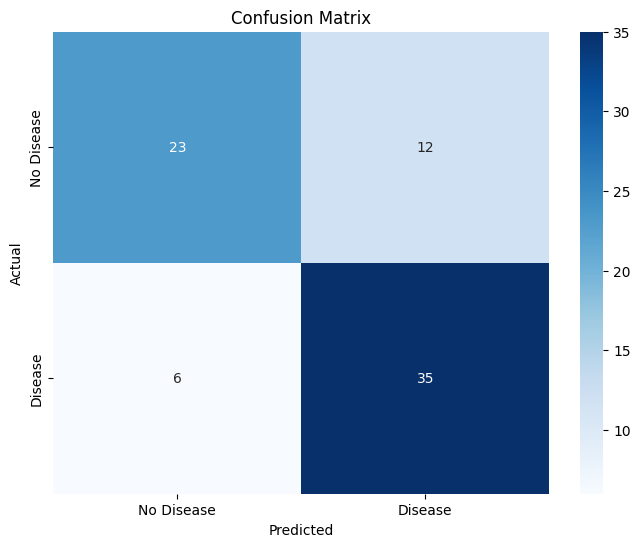

In [11]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---
## 3. ROC Curve and AUC

### ROC Curve (Receiver Operating Characteristic)
Plots **True Positive Rate (Recall)** vs **False Positive Rate** at various threshold settings.

- **TPR (Sensitivity)** = TP / (TP + FN)
- **FPR** = FP / (FP + TN)

### AUC (Area Under the Curve)
- **AUC = 1.0**: Perfect classifier
- **AUC = 0.5**: Random classifier (no discrimination)
- **AUC > 0.8**: Generally considered good

AUC represents the probability that a randomly chosen positive example is ranked higher than a randomly chosen negative example.

In [12]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8474


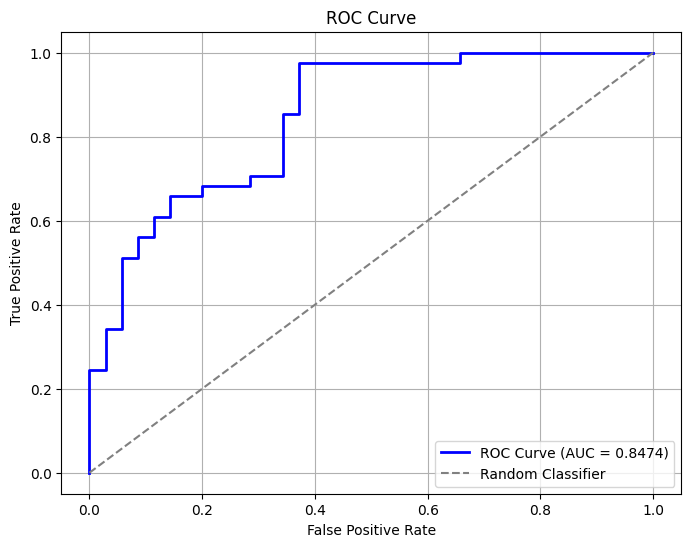

In [13]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---
## 4. Precision-Recall Curve

The **Precision-Recall Curve** is especially useful for **imbalanced datasets** where the positive class is rare.

- Plots Precision vs Recall at various thresholds
- A high area under this curve means both high recall and high precision
- More informative than ROC when dealing with class imbalance

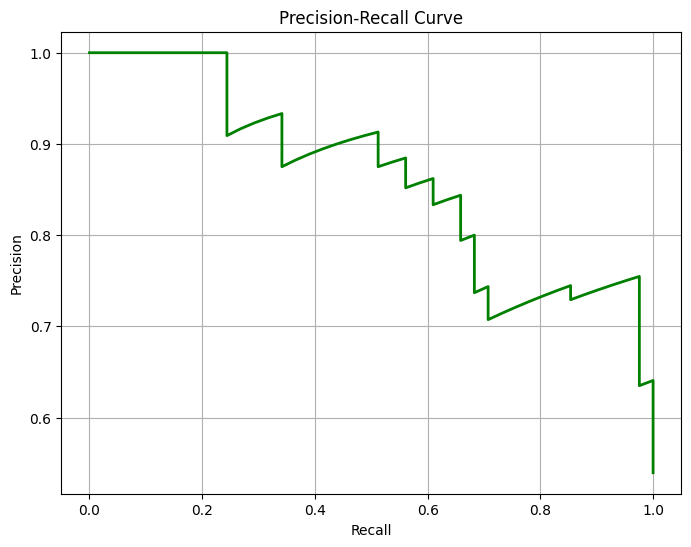

In [14]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

---
## 5. Cross-Validation

**Cross-Validation** is a technique to evaluate model performance more reliably by:
1. Splitting data into k equal parts (folds)
2. Training on k-1 folds, testing on 1 fold
3. Repeating k times, each fold serving as test set once
4. Averaging results across all folds

### Benefits:
- Uses all data for both training and validation
- Reduces variance in performance estimation
- Detects overfitting

### Types:
- **K-Fold**: Standard k-fold split
- **Stratified K-Fold**: Maintains class distribution in each fold (use for classification)
- **Leave-One-Out (LOO)**: k = number of samples (computationally expensive)

In [15]:
# Simple cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

CV Scores: [0.82608696 0.80434783 0.77777778 0.86666667 0.91111111]
Mean CV Score: 0.8372
Std CV Score: 0.0470


In [16]:
# Stratified K-Fold (maintains class distribution)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), 1):
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model_fold = LogisticRegression(random_state=42)
    model_fold.fit(X_fold_train, y_fold_train)
    score = model_fold.score(X_fold_val, y_fold_val)
    fold_scores.append(score)
    print(f"Fold {fold}: {score:.4f}")

print(f"\nMean: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

Fold 1: 0.8043
Fold 2: 0.8696
Fold 3: 0.8222
Fold 4: 0.8222
Fold 5: 0.8222

Mean: 0.8281 (+/- 0.0219)


---
## 6. Cross-Validation with Multiple Metrics

In [17]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

accuracy: 0.8372 (+/- 0.0470)
precision: 0.8345 (+/- 0.0424)
recall: 0.8797 (+/- 0.0755)
f1: 0.8545 (+/- 0.0444)
roc_auc: 0.9155 (+/- 0.0281)


---
## 7. Comparing Multiple Models

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'Mean Accuracy': cv_scores.mean(),
        'Std': cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values('Mean Accuracy', ascending=False)
results_df

,Model,Mean Accuracy,Std
4,KNN,0.854686,0.052784
2,Random Forest,0.845894,0.074802
3,SVM,0.841546,0.042088
0,Logistic Regression,0.837198,0.047042
1,Decision Tree,0.797971,0.070808


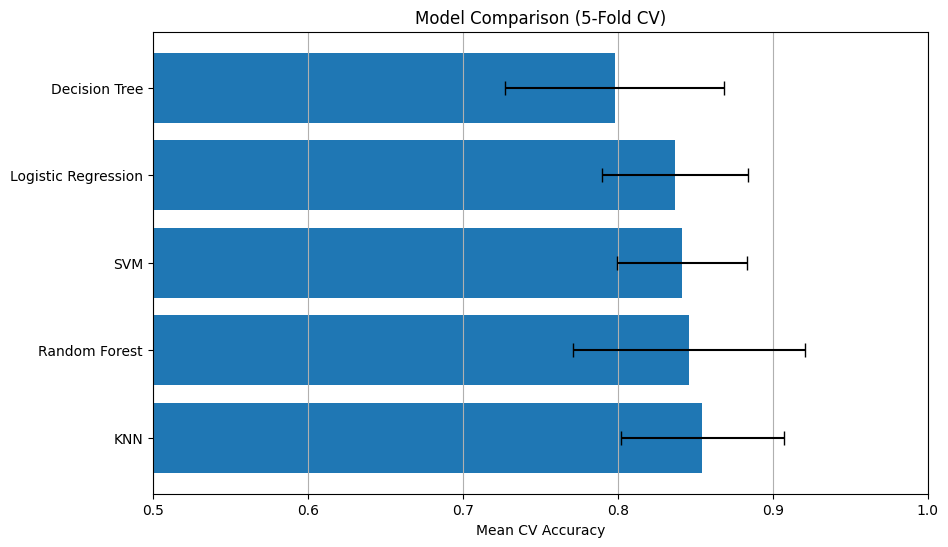

In [19]:
# Visualize model comparison
plt.figure(figsize=(10, 6))
plt.barh(results_df['Model'], results_df['Mean Accuracy'], xerr=results_df['Std'], capsize=5)
plt.xlabel('Mean CV Accuracy')
plt.title('Model Comparison (5-Fold CV)')
plt.xlim(0.5, 1.0)
plt.grid(axis='x')
plt.show()

---
## 8. Regression Metrics

For regression problems, we use different metrics:

### MAE (Mean Absolute Error)
Average of absolute differences between predictions and actual values. Easy to interpret - in same units as target.

### MSE (Mean Squared Error)
Average of squared differences. Penalizes larger errors more heavily.

### RMSE (Root Mean Squared Error)
Square root of MSE. Same units as target, commonly used.

### R² (Coefficient of Determination)
Proportion of variance explained by the model. R² = 1 is perfect, R² = 0 means model is no better than predicting the mean.

In [20]:
# Example with regression data
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

In [21]:
print("Regression Metrics:")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_reg_test, y_reg_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}")
print(f"R²:   {r2_score(y_reg_test, y_reg_pred):.4f}")

Regression Metrics:
MAE:  15.6138
MSE:  353.3567
RMSE: 18.7978
R²:   0.9585


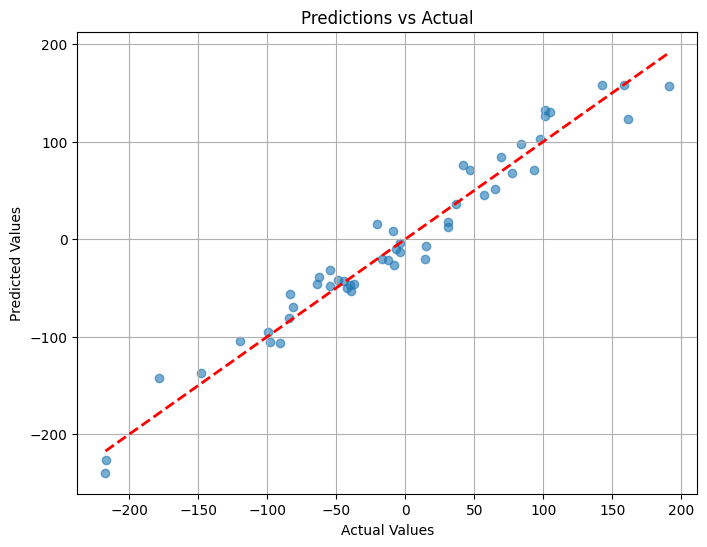

In [22]:
# Visualize predictions vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predictions vs Actual')
plt.grid(True)
plt.show()

---
## 9. Summary: When to Use Which Metric

| Metric | Use When |
|--------|----------|
| **Accuracy** | Balanced classes, equal cost of errors |
| **Precision** | False positives are costly (spam detection) |
| **Recall** | False negatives are costly (disease detection) |
| **F1-Score** | Need balance between precision and recall |
| **AUC-ROC** | Need threshold-independent evaluation |
| **Precision-Recall Curve** | Imbalanced datasets |
| **MAE** | Outliers should not dominate (regression) |
| **RMSE** | Large errors should be penalized (regression) |
| **R²** | Compare relative model performance (regression) |